<a href="https://colab.research.google.com/github/anshulsharma200817-svg/data_analyticsusingpythonassesments/blob/main/module5and6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MODULE 5&6 ASSIGNMENT EDA_Statistical_Analysis:  
NAME-ANSHUL SHARMA   
COURSE-DATA ANALYTICS WITH PYTHON   
SECTION-H   
ROLL NO-BETN1AI25061  

### Chi-Square Test for Categorical Variables

To perform a Chi-square test, we need categorical variables. We will create two new categorical variables from existing numerical ones:
1.  **`age_category`**: Discretize `housing_median_age` into 'Young' and 'Old' based on its median.
2.  **`value_category`**: Discretize `median_house_value` into 'Low' and 'High' based on its median.

In [11]:
from scipy.stats import chi2_contingency

# Create 'age_category' from 'housing_median_age'
median_age_threshold = df['housing_median_age'].median()
df['age_category'] = df['housing_median_age'].apply(lambda x: 'Young' if x <= median_age_threshold else 'Old')

# Create 'value_category' from 'median_house_value'
median_value_threshold = df['median_house_value'].median()
df['value_category'] = df['median_house_value'].apply(lambda x: 'Low' if x <= median_value_threshold else 'High')

# Create a contingency table
contingency_table = pd.crosstab(df['age_category'], df['value_category'])
display(contingency_table)

# Perform Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

alpha = 0.05
print(f"Significance level (alpha): {alpha}")

if p < alpha:
    print("Conclusion: Since the p-value is less than alpha, we reject the null hypothesis.")
    print("This suggests there is a statistically significant association between housing median age category and median house value category.")
else:
    print("Conclusion: Since the p-value is greater than alpha, we fail to reject the null hypothesis.")
    print("This suggests there is no statistically significant association between housing median age category and median house value category.")

print("Interpretation: The Chi-square test assesses whether there is a significant association between two categorical variables. In this case, we are checking if the category of housing median age (Young/Old) is related to the category of median house value (Low/High). A low p-value (typically < 0.05) indicates that the observed association is unlikely due to random chance, suggesting a real relationship between the categories. Conversely, a high p-value would suggest no significant association.")

value_category,High,Low
age_category,,
Old,4257,3932
Young,4235,4576



Chi-square statistic: 25.9241
P-value: 0.0000
Degrees of freedom: 1
Significance level (alpha): 0.05
Conclusion: Since the p-value is less than alpha, we reject the null hypothesis.
This suggests there is a statistically significant association between housing median age category and median house value category.
Interpretation: The Chi-square test assesses whether there is a significant association between two categorical variables. In this case, we are checking if the category of housing median age (Young/Old) is related to the category of median house value (Low/High). A low p-value (typically < 0.05) indicates that the observed association is unlikely due to random chance, suggesting a real relationship between the categories. Conversely, a high p-value would suggest no significant association.


In [10]:
from scipy import stats

# Calculate the median housing_median_age to split the dataset
median_age_threshold = df['housing_median_age'].median()

# Create two groups based on housing_median_age
group1 = df[df['housing_median_age'] <= median_age_threshold]['median_house_value']
group2 = df[df['housing_median_age'] > median_age_threshold]['median_house_value']

print(f"Group 1 (Housing Median Age <= {median_age_threshold}): {len(group1)} samples")
print(f"Group 2 (Housing Median Age > {median_age_threshold}): {len(group2)} samples")

# Perform independent samples t-test
t_statistic, p_value = stats.ttest_ind(group1, group2, equal_var=False) # Assuming unequal variances

print(f"\nIndependent Samples t-test results:")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
print(f"Significance level (alpha): {alpha}")

if p_value < alpha:
    print("Conclusion: Since the p-value is less than alpha, we reject the null hypothesis.")
    print("This suggests there is a statistically significant difference in median house values between districts with younger and older median housing ages.")
else:
    print("Conclusion: Since the p-value is greater than alpha, we fail to reject the null hypothesis.")
    print("This suggests there is no statistically significant difference in median house values between districts with younger and older median housing ages.")

print("Interpretation: The t-test helps us determine if the means of two independent groups are significantly different. In this case, we compared the median house values between areas with relatively younger and older housing stocks. A low p-value (typically < 0.05) would indicate that the observed difference is unlikely to be due to random chance, suggesting a real difference in house values based on the age of houses. Conversely, a high p-value would suggest no significant difference.")

Group 1 (Housing Median Age <= 29.0): 8811 samples
Group 2 (Housing Median Age > 29.0): 8189 samples

Independent Samples t-test results:
T-statistic: -9.0894
P-value: 0.0000
Significance level (alpha): 0.05
Conclusion: Since the p-value is less than alpha, we reject the null hypothesis.
This suggests there is a statistically significant difference in median house values between districts with younger and older median housing ages.
Interpretation: The t-test helps us determine if the means of two independent groups are significantly different. In this case, we compared the median house values between areas with relatively younger and older housing stocks. A low p-value (typically < 0.05) would indicate that the observed difference is unlikely to be due to random chance, suggesting a real difference in house values based on the age of houses. Conversely, a high p-value would suggest no significant difference.


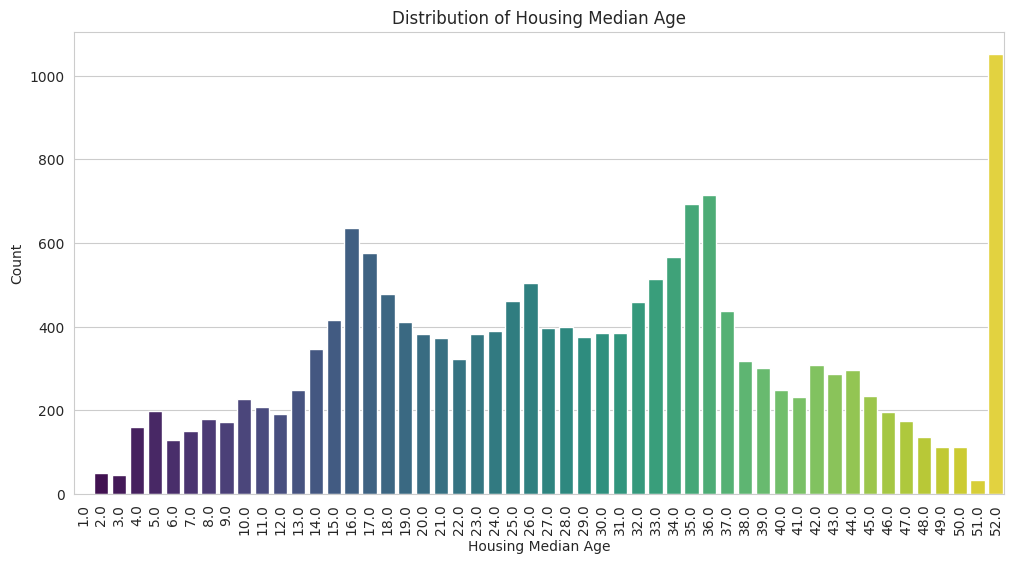

Interpretation: This bar chart shows the frequency of different 'housing_median_age' values. Each bar represents a specific median age of houses, and its height indicates how many districts have that particular median age. This helps us understand the age profile of the housing stock in the dataset, identifying which age ranges are most common.


In [9]:
plt.figure(figsize=(12, 6))
sns.countplot(x=df['housing_median_age'], hue=df['housing_median_age'], palette='viridis', legend=False)
plt.title('Distribution of Housing Median Age')
plt.xlabel('Housing Median Age')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

print("Interpretation: This bar chart shows the frequency of different 'housing_median_age' values. Each bar represents a specific median age of houses, and its height indicates how many districts have that particular median age. This helps us understand the age profile of the housing stock in the dataset, identifying which age ranges are most common.")

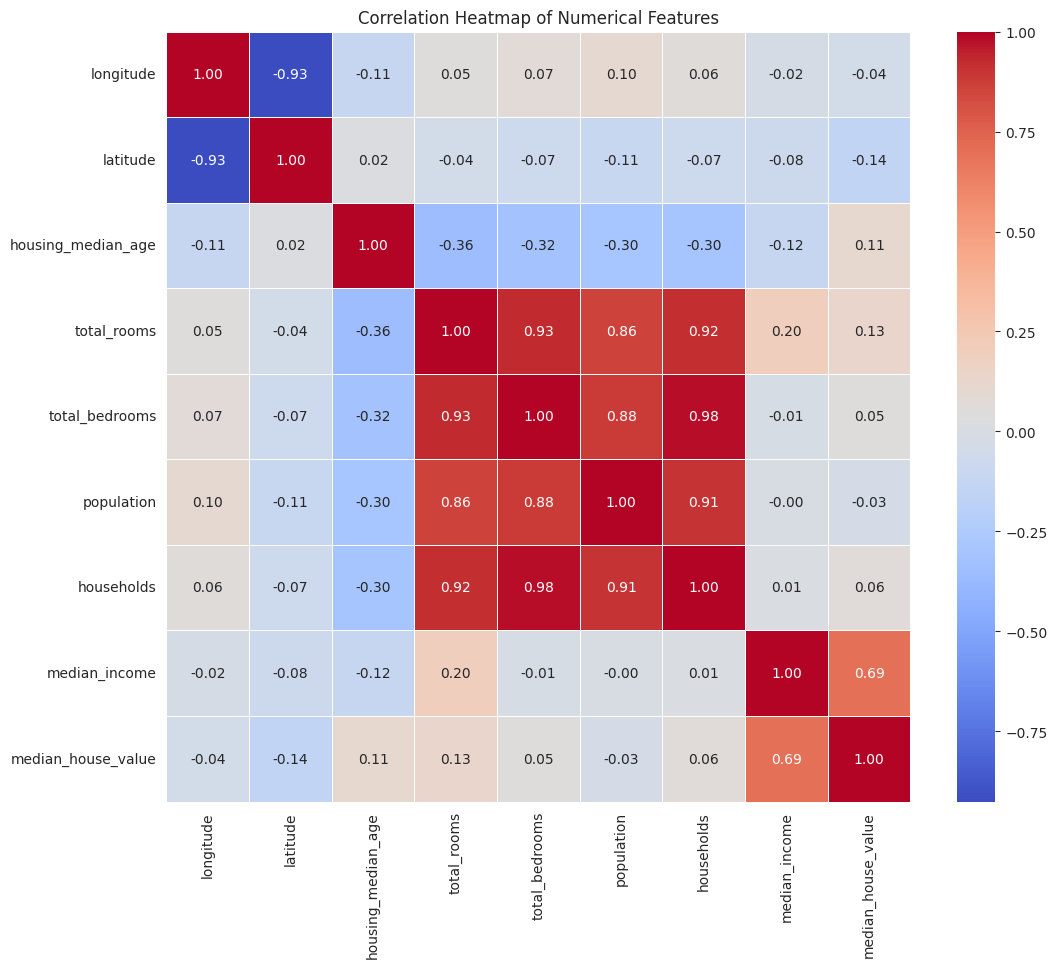

Interpretation: This heatmap displays the correlation coefficients between all numerical features in the dataset. Values close to +1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values near 0 indicate little to no linear correlation. This helps us understand the relationships between variables, for instance, which features might heavily influence 'median_house_value'.


In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

print("Interpretation: This heatmap displays the correlation coefficients between all numerical features in the dataset. Values close to +1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values near 0 indicate little to no linear correlation. This helps us understand the relationships between variables, for instance, which features might heavily influence 'median_house_value'.")

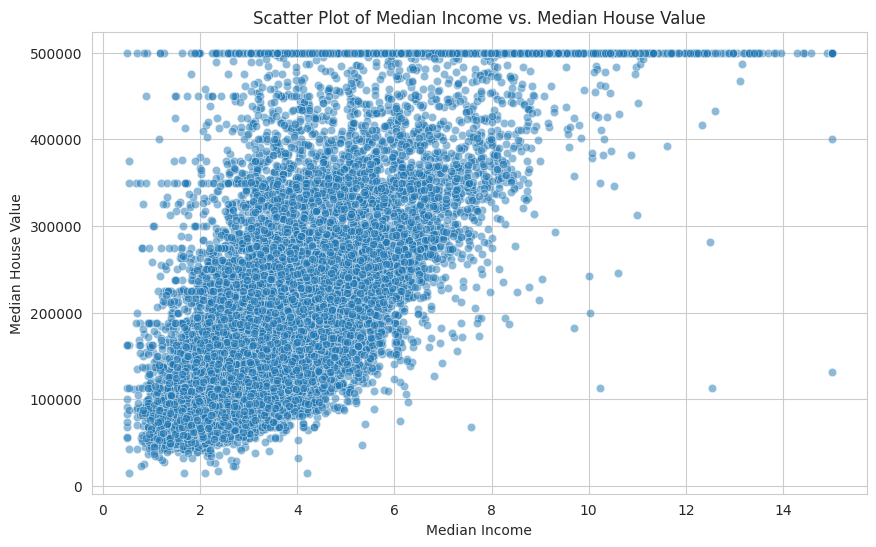

Interpretation: This scatter plot visualizes the relationship between median income and median house value. We can observe if there's a positive or negative correlation, the strength of that relationship, and if there are any distinct clusters or outliers. For instance, we might expect higher median incomes to correspond to higher median house values.


In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['median_income'], y=df['median_house_value'], alpha=0.5)
plt.title('Scatter Plot of Median Income vs. Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

print("Interpretation: This scatter plot visualizes the relationship between median income and median house value. We can observe if there's a positive or negative correlation, the strength of that relationship, and if there are any distinct clusters or outliers. For instance, we might expect higher median incomes to correspond to higher median house values.")

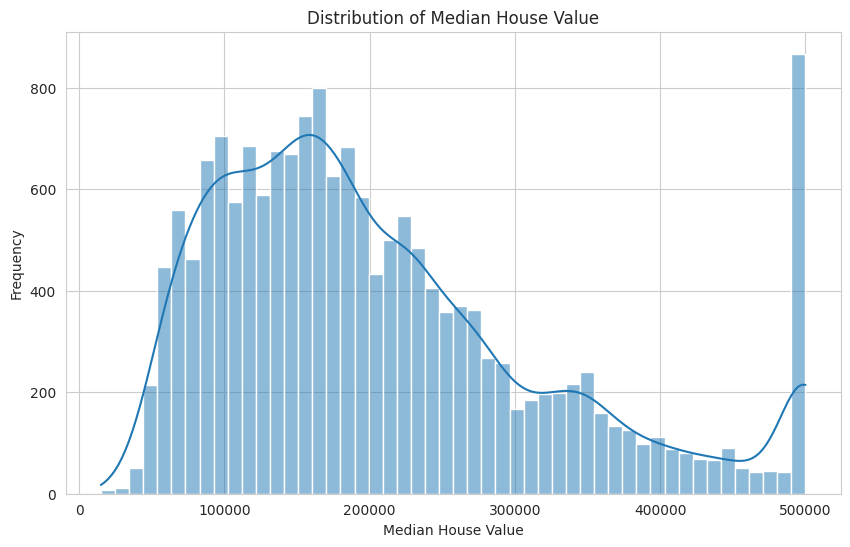

Interpretation: This histogram shows the distribution of median house values. We can observe the frequency of different price ranges. A significant peak indicates the most common price range, and the tail of the distribution can reveal if there are many high-value or low-value houses.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create a histogram for 'median_house_value'
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], bins=50, kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

print("Interpretation: This histogram shows the distribution of median house values. We can observe the frequency of different price ranges. A significant peak indicates the most common price range, and the tail of the distribution can reveal if there are many high-value or low-value houses.")

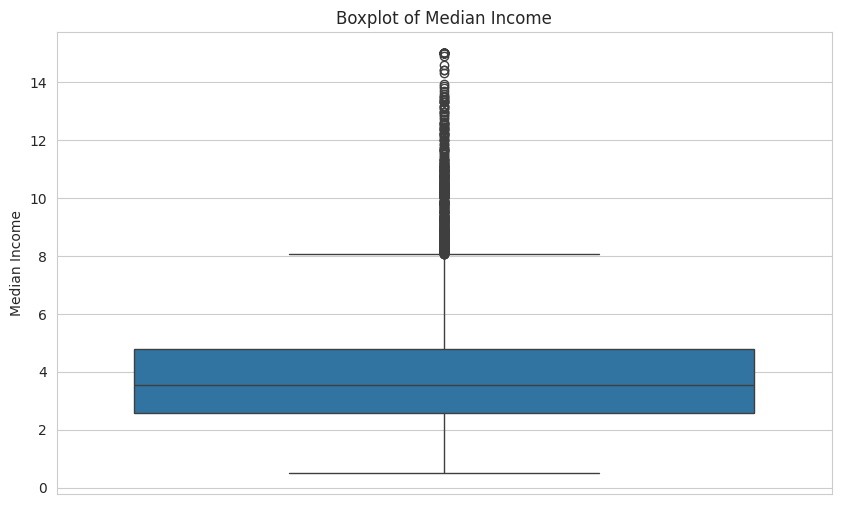

Interpretation: This boxplot illustrates the distribution of median income. The box represents the interquartile range (IQR), with the line inside indicating the median. The 'whiskers' extend to the most extreme data points within 1.5 times the IQR from the box. Points outside the whiskers are considered outliers, suggesting unusual income levels in those areas.


In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['median_income'])
plt.title('Boxplot of Median Income')
plt.ylabel('Median Income')
plt.show()

print("Interpretation: This boxplot illustrates the distribution of median income. The box represents the interquartile range (IQR), with the line inside indicating the median. The 'whiskers' extend to the most extreme data points within 1.5 times the IQR from the box. Points outside the whiskers are considered outliers, suggesting unusual income levels in those areas.")

In [2]:
import pandas as pd

# Load the California Housing dataset
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [3]:
# Display basic information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB
